## Introducción

## Setup del entorno

In [24]:
# Importamos las librerias necesarias:
from diffusers import StableDiffusionPipeline, DDPMScheduler
from diffusers import UNet2DConditionModel, AutoencoderKL, LMSDiscreteScheduler
from transformers import CLIPTextModel, CLIPTokenizer
from datasets import load_dataset
from accelerate import Accelerator
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
from tqdm import tqdm

from dotenv import load_dotenv
from huggingface_hub import login

import gc


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cpu


## Modelo pre-entrenado (Comportamiento original)

In [ ]:

# 1. Esto busca el archivo .env y carga sus variables en el entorno
load_dotenv()

# 2. Recuperamos el valor de la variable de forma segura
mi_token_hf = os.getenv("HF_TOKEN")

# 3. Iniciamos sesión en Hugging Face
login(token=mi_token_hf)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [6]:
pretrained_model_name = "CompVis/stable-diffusion-v1-4"

# Cargamos un modelo pre-entrenado Stable Diffusion:
pipe = StableDiffusionPipeline.from_pretrained(
    pretrained_model_name,
).to(device)

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

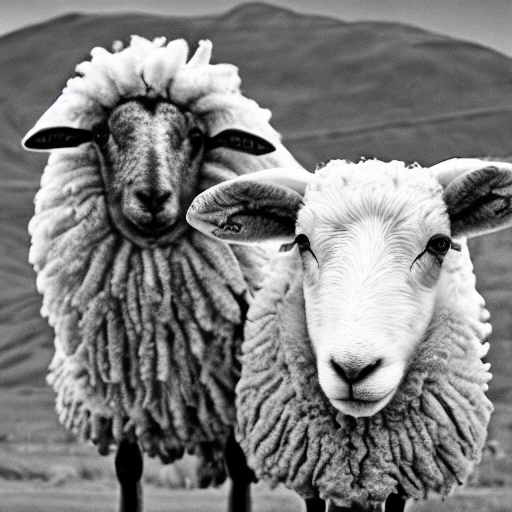

In [7]:
# Vamos a generar una imagen con un prompt:
prompt = "an image of a crazy sheep"
image = pipe(prompt).images[0]

image

## Cargamos el dataset para finetunear

In [10]:
# Cargando el dataset de libros antiguos con texto:
dataset_name = "gigant/oldbookillustrations"
max_train_samples = 100  # tiene que ser menor que 4.15K (el numero de filas que tiene el dataset original)


dataset = load_dataset(dataset_name, split="train")
if max_train_samples:
    dataset = dataset.select(range(max_train_samples))


data/train-00000-of-00013-c0326990f575de(…):   0%|          | 0.00/628M [00:00<?, ?B/s]

data/train-00001-of-00013-a511e1086f1718(…):   0%|          | 0.00/439M [00:00<?, ?B/s]

data/train-00002-of-00013-ae73a77722dcbf(…):   0%|          | 0.00/424M [00:00<?, ?B/s]

data/train-00003-of-00013-35d02b418784cb(…):   0%|          | 0.00/363M [00:00<?, ?B/s]

data/train-00004-of-00013-0ad17a1426c919(…):   0%|          | 0.00/344M [00:00<?, ?B/s]

...

data/train-00009-of-00013-7e18348b50d9c8(…):   0%|          | 0.00/354M [00:00<?, ?B/s]

data/train-00010-of-00013-dc5f8380886ecc(…):   0%|          | 0.00/432M [00:00<?, ?B/s]

data/train-00011-of-00013-2e765ba2d2b351(…):   0%|          | 0.00/366M [00:00<?, ?B/s]

data/train-00012-of-00013-cf490ec155e3b8(…):   0%|          | 0.00/388M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4154 [00:00<?, ? examples/s]

In [12]:
#Inspeccionar dataset

print(dataset)
print(dataset.column_names)

Dataset({
    features: ['rawscan', '1600px', 'info_url', 'info_src', 'info_alt', 'artist_name', 'artist_birth_date', 'artist_death_date', 'artist_countries', 'book_title', 'book_authors', 'book_publishers', 'date_published', 'openlibrary-url', 'tags', 'illustration_source_name', 'illustration_source_url', 'illustration_subject', 'illustration_format', 'engravers', 'image_title', 'image_caption', 'image_description', 'rawscan_url', '1600px_url'],
    num_rows: 100
})
['rawscan', '1600px', 'info_url', 'info_src', 'info_alt', 'artist_name', 'artist_birth_date', 'artist_death_date', 'artist_countries', 'book_title', 'book_authors', 'book_publishers', 'date_published', 'openlibrary-url', 'tags', 'illustration_source_name', 'illustration_source_url', 'illustration_subject', 'illustration_format', 'engravers', 'image_title', 'image_caption', 'image_description', 'rawscan_url', '1600px_url']


In [ ]:
#Comprobamos tamaño de una imagen del dataset

size = dataset[0]["1600px"].size
print(f"Tamaño de las imagenes del dataset: {size}")

Tamaño de las imagenes del dataset: (1158, 1600)


In [17]:
# Definimos las transformaciones necesarias para el dataset:
# La resolucion del modelo la podemos encontrar en su model card:
resolution = 512
image_transforms = transforms.Compose([
    transforms.Resize((resolution, resolution)),             # resizing
    transforms.ToTensor(),                                   # convertir a tensor
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),  # normalizacion
])

Imagen transformada:


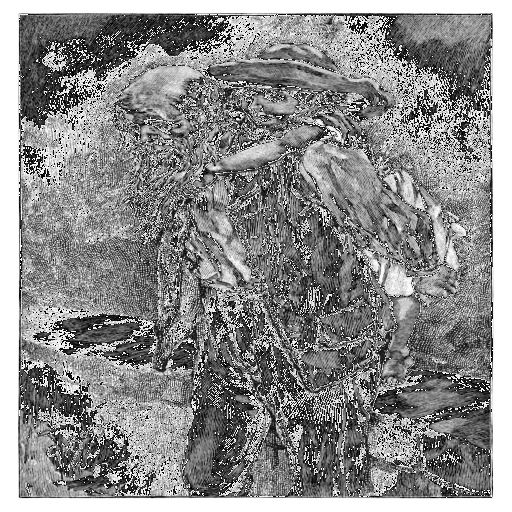

In [18]:
# Aplicamos la transformacion a la primera imagen del dataset:
original_image = dataset[0]["1600px"]
transformed_image = image_transforms(original_image)
transformed_pil_image = transforms.ToPILImage()(transformed_image)

print("Imagen transformada:")
transformed_pil_image

In [ ]:
# Creamos un Dataset wrapper para la hora del entrenamiento

batch_size = 2

class Text2ImageDataset(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        example = self.dataset[idx]
        image = image_transforms(example["1600px"].convert("RGB"))      
        token = tokenizer(example["info_alt"], padding="max_length", truncation=True, max_length=tokenizer.model_max_length,
                return_tensors="pt")
        return {
            "pixel_values": image,
            "input_ids": token.input_ids.squeeze(0),
            "attention_mask": token.attention_mask.squeeze(0),
        }

train_dataset = Text2ImageDataset(dataset)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

## Cargamos las componentes del modelo por separado

In [25]:
# Liberamos el pipe que ya no necesitamos para hacer sitio en memoria:

if "pipe" in globals():
    del pipe
gc.collect()

29447

In [26]:
# Tokenizador:
tokenizer = CLIPTokenizer.from_pretrained(pretrained_model_name, subfolder='tokenizer')

# Scheduler:
noise_scheduler = DDPMScheduler.from_pretrained(pretrained_model_name, subfolder="scheduler")

# Text Encoder (CLIP):
text_encoder = CLIPTextModel.from_pretrained(
    pretrained_model_name,
    subfolder="text_encoder",
).to(device)

# VAE: Autoencoder:
vae = AutoencoderKL.from_pretrained(
    pretrained_model_name,
    subfolder="vae",
).to(device)

# La UNet:
unet = UNet2DConditionModel.from_pretrained(
    pretrained_model_name,
    subfolder="unet",
).to(device)

c:\Users\victo\Pontia\Modulo_7\Entrega_Final_Modulo_7\venv\Lib\site-packages\huggingface_hub\utils\_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

In [27]:
# Congelamos los pesos del VAE y del Text Encoder, ya que solo queremos finetunear la UNet:
vae.eval()
text_encoder.eval()

for param in vae.parameters():
    param.requires_grad = False
for param in text_encoder.parameters():
    param.requires_grad = False